In [18]:
import sqlite3

conn = sqlite3.connect("northwind.db")

In [20]:
import pandas as pd

In [21]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)
tables

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


In [22]:
pd.read_sql("SELECT * FROM Products LIMIT 5;", conn)

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


In [23]:
pd.read_sql("SELECT * FROM Orders LIMIT 5;", conn)

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,Reims,Western Europe,51100,France
1,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,Münster,Western Europe,44087,Germany
2,10250,HANAR,4,2016-07-08,2016-08-05,2016-07-12,2,25.00,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,South America,05454-876,Brazil
3,10251,VICTE,3,2016-07-08,2016-08-05,2016-07-15,1,20.25,Victuailles en stock,"2, rue du Commerce",Lyon,Western Europe,69004,France
4,10252,SUPRD,4,2016-07-09,2016-08-06,2016-07-11,2,36.25,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,Western Europe,B-6000,Belgium


In [24]:
pd.read_sql('SELECT * FROM "Order Details" LIMIT 5;', conn)

,OrderID,ProductID,UnitPrice,Quantity,Discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0
3,10249,14,18.6,9,0.0
4,10249,51,42.4,40,0.0


In [25]:
query = """
SELECT
    p.ProductName,
    SUM(od.Quantity) AS TotalSold
FROM Products p
JOIN "Order Details" od
ON p.ProductID = od.ProductID
GROUP BY p.ProductName
ORDER BY TotalSold DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, conn)
top_products

,ProductName,TotalSold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


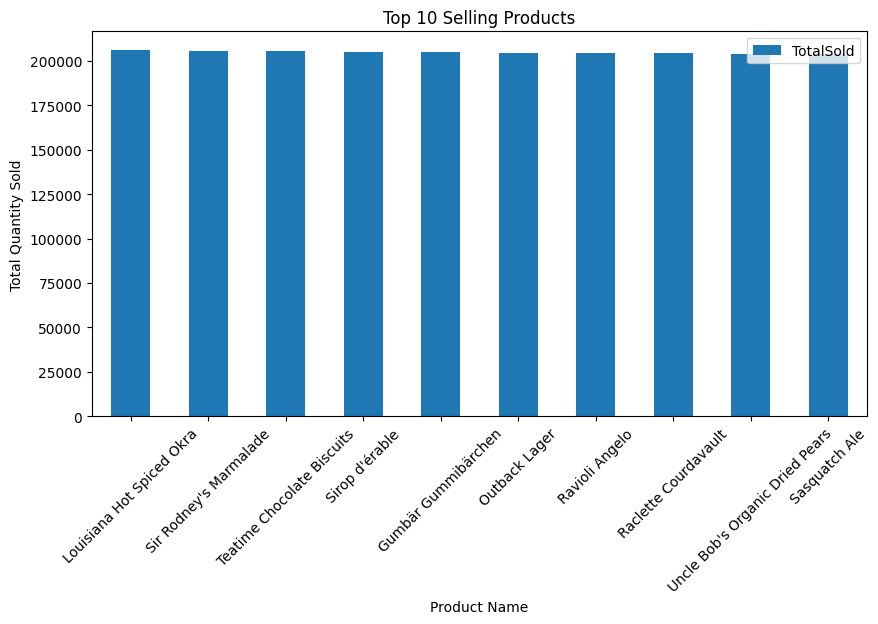

In [26]:
import matplotlib.pyplot as plt

top_products.plot(
    x="ProductName",
    y="TotalSold",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [27]:
query = """
SELECT
    c.CompanyName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Revenue
FROM Customers c
JOIN Orders o
    ON c.CustomerID = o.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
GROUP BY c.CompanyName
ORDER BY Revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, conn)
top_customers

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.81
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524517.31
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462198.02
9,LILA-Supermercado,5437438.34


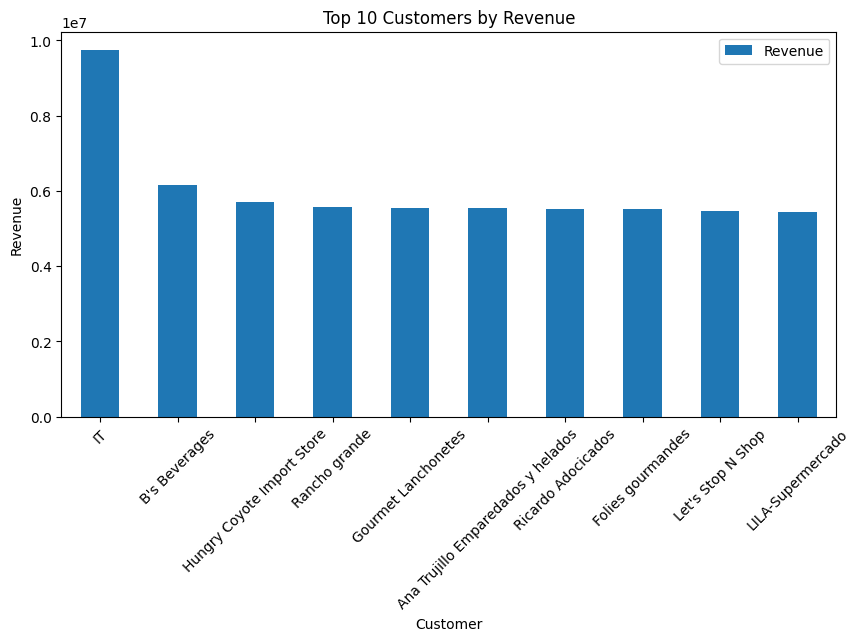

In [28]:
import matplotlib.pyplot as plt

top_customers.plot(
    x="CompanyName",
    y="Revenue",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [29]:
query = """
SELECT
    strftime('%Y-%m', o.OrderDate) AS Month,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Sales
FROM Orders o
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql(query, conn)
monthly_sales

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51


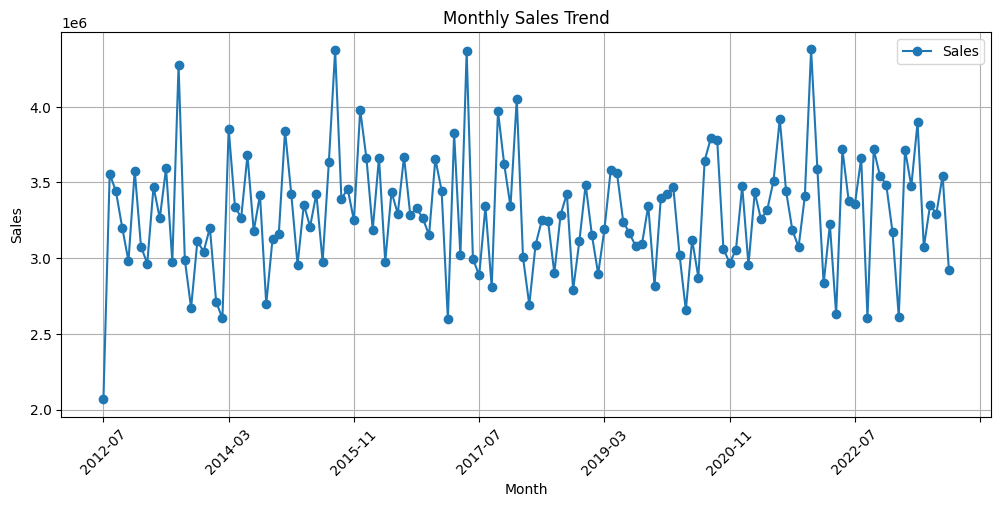

In [30]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    x="Month",
    y="Sales",
    kind="line",
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [31]:
query = """
SELECT
    c.CategoryName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Revenue
FROM Categories c
JOIN Products p
    ON c.CategoryID = p.CategoryID
JOIN "Order Details" od
    ON p.ProductID = od.ProductID
GROUP BY c.CategoryName
ORDER BY Revenue DESC;
"""

categories = pd.read_sql(query, conn)
categories

,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34


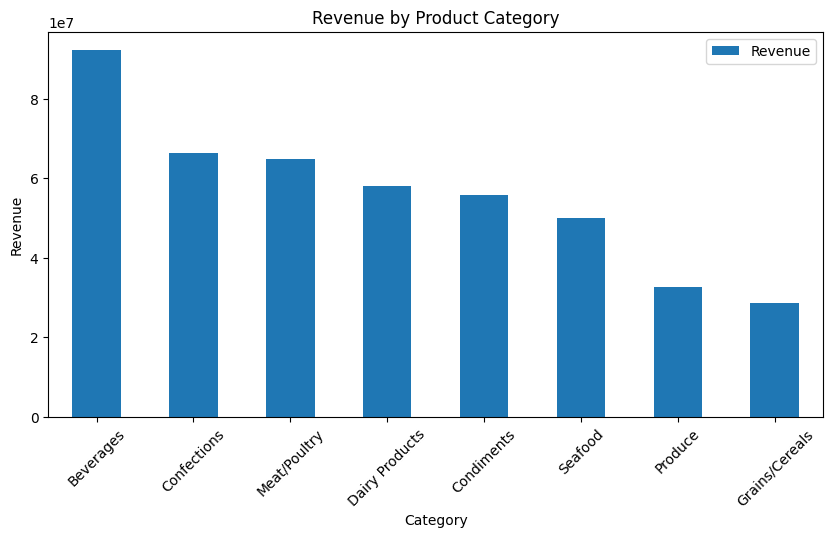

In [32]:
import matplotlib.pyplot as plt

categories.plot(
    x="CategoryName",
    y="Revenue",
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [33]:
query = """
SELECT
    c.CompanyName,
    COUNT(o.OrderID) AS TotalOrders
FROM Customers c
JOIN Orders o
    ON c.CustomerID = o.CustomerID
GROUP BY c.CompanyName
ORDER BY TotalOrders DESC;
"""

purchase_frequency = pd.read_sql(query, conn)
purchase_frequency

,CompanyName,TotalOrders
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202
...,...,...
87,Around the Horn,156
88,La corne d'abondance,155
89,Furia Bacalhau e Frutos do Mar,155
90,FISSA Fabrica Inter. Salchichas S.A.,155


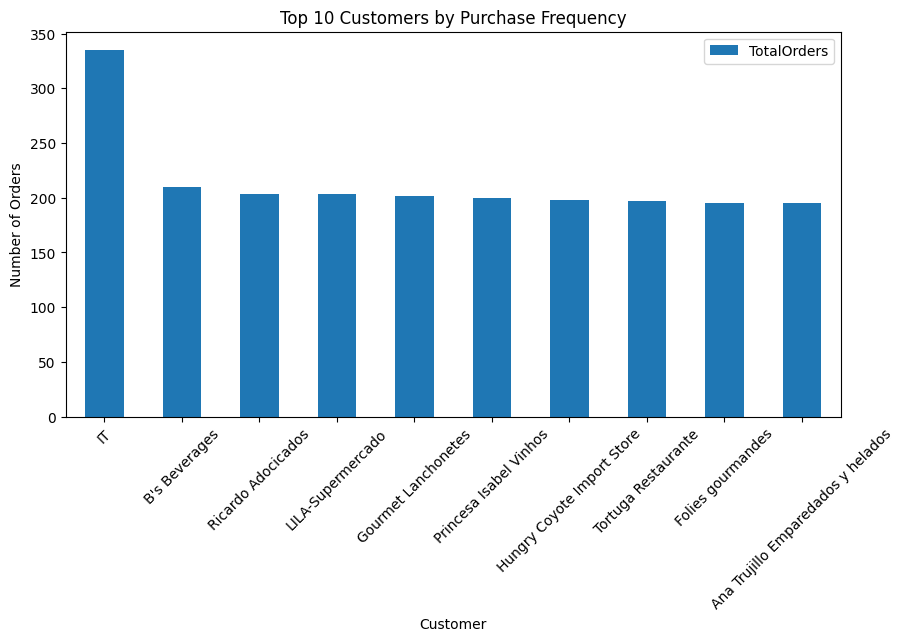

In [34]:
top10_frequency = purchase_frequency.head(10)

top10_frequency.plot(
    x="CompanyName",
    y="TotalOrders",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [35]:
top_products.head()

,ProductName,TotalSold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761


In [36]:
top_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ProductName  10 non-null     object
 1   TotalSold    10 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 292.0+ bytes


In [37]:
top_products.describe()

,TotalSold
count,10.000000
mean,204753.100000
std,820.692452
min,203667.000000
25%,204165.500000
50%,204582.000000
75%,205366.500000
max,206213.000000


In [38]:
top_products.isnull().sum()

,0
ProductName,0
TotalSold,0


In [39]:
top_customers.head()
top_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CompanyName  10 non-null     object 
 1   Revenue      10 non-null     float64
dtypes: float64(1), object(1)
memory usage: 292.0+ bytes


In [40]:
top_customers.head()

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.81


In [41]:
top_customers.describe()

,Revenue
count,1.000000e+01
mean,6.017294e+06
std,1.326135e+06
min,5.437438e+06
25%,5.510256e+06
50%,5.543333e+06
75%,5.663295e+06
max,9.745371e+06


In [42]:
top_customers.isnull().sum()

,0
CompanyName,0
Revenue,0


In [43]:
monthly_sales.head()

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74


In [44]:
monthly_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   136 non-null    object 
 1   Sales   136 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.3+ KB


In [45]:
monthly_sales.describe()

,Sales
count,1.360000e+02
mean,3.296961e+06
std,3.885097e+05
min,2.066219e+06
25%,3.050957e+06
50%,3.285466e+06
75%,3.518739e+06
max,4.377795e+06


In [46]:
monthly_sales.isnull().sum()

,0
Month,0
Sales,0


In [47]:
categories.head()

,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78


In [48]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CategoryName  8 non-null      object 
 1   Revenue       8 non-null      float64
dtypes: float64(1), object(1)
memory usage: 260.0+ bytes


In [49]:
categories.describe()

,Revenue
count,8.000000e+00
mean,5.604833e+07
std,2.010646e+07
min,2.856853e+07
25%,4.561648e+07
50%,5.690662e+07
75%,6.524531e+07
max,9.216318e+07


In [50]:
categories.isnull().sum()

,0
CategoryName,0
Revenue,0


In [51]:
purchase_frequency.head()

,CompanyName,TotalOrders
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202


In [52]:
purchase_frequency.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CompanyName  92 non-null     object
 1   TotalOrders  92 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [53]:
purchase_frequency.describe()

,TotalOrders
count,92.000000
mean,176.978261
std,20.942086
min,154.000000
25%,165.750000
50%,175.000000
75%,184.250000
max,335.000000


In [54]:
purchase_frequency.isnull().sum()

,0
CompanyName,0
TotalOrders,0


In [55]:
queries = """
-- Query 1: Top 10 Selling Products
<PASTE QUERY 1 HERE>

-- Query 2: Top 10 Customers by Revenue
<PASTE QUERY 2 HERE>

-- Query 3: Monthly Sales Trends
<PASTE QUERY 3 HERE>

-- Query 4: Best Performing Product Categories
<PASTE QUERY 4 HERE>

-- Query 5: Customer Purchase Frequency
<PASTE QUERY 5 HERE>
"""

with open("queries.sql", "w") as file:
    file.write(queries)

print("queries.sql created successfully!")

queries.sql created successfully!


## Business Insights

1. The highest-selling product is **<Product Name>**, with **<Quantity>** units sold.

2. The customer generating the highest revenue is **<Customer Name>**, contributing **<Revenue>**.

3. Monthly sales reached their peak in **<Month>**, indicating a period of strong demand.

4. The **<Category Name>** category generated the highest revenue among all product categories.

5. **<Customer Name>** placed the highest number of orders, indicating strong customer loyalty.